Data Cleaning and Visualization Using Python - Mormoo5363 - SDC380 - 2.4 Performance Assessment - 03/16/2026

In [2]:
!pip install pandas numpy matplotlib openpyxl

  Using cached pandas-3.0.1-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached pandas-3.0.1-cp311-cp311-win_amd64.whl (9.9 MB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from datetime import datetime

In [7]:
today_date = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
student_id = "Mormoo5363"

# Change this to your actual file path
file_path = r"C:\Users\Morgan Moore\Downloads\AirBnBSummary_v2.xlsx"

# Load dataset
df = pd.read_excel(file_path)

display(Markdown(f"## {student_id} - {today_date}"))
display(Markdown("### First 5 rows of original dataset"))
display(df.head())

## Mormoo5363 - 2026-03-16 15:08:42

### First 5 rows of original dataset

,id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
0,7909479,41706311,David,Downtown,Entire home/apt,107.0,30,27,365.0,NaN
1,15966488,103700433,Erin,Downtown,Entire home/apt,100.0,1,250,74.0,NaN
2,19859814,103700433,Erin,Downtown,Entire home/apt,100.0,1,309,79.0,NaN
3,21071138,22992627,Joseph,Downtown,Entire home/apt,100.0,2,144,338.0,NaN
4,21712505,103700433,Erin,Downtown,Entire home/apt,100.0,1,178,68.0,NaN


In [8]:
duplicate_rows_before = df[df.duplicated()]

display(Markdown(f"## {student_id} - {today_date}"))
display(Markdown("### Duplicate rows before cleaning"))
display(duplicate_rows_before)

df_cleaned = df.copy()
df_cleaned.drop_duplicates(inplace=True)

duplicate_rows_after = df_cleaned[df_cleaned.duplicated()]

display(Markdown("### Duplicate rows after cleaning"))
display(duplicate_rows_after)

## Mormoo5363 - 2026-03-16 15:08:42

### Duplicate rows before cleaning

,id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
1775,27252097,205256572,Stephanie,West Olentangy,Entire home/apt,296.0,1,164,167.0,NaN
1776,28640445,181661236,Chris,West Olentangy,Entire home/apt,105.0,2,280,170.0,NaN
1777,620815000000000000,453019578,Devon,West Olentangy,Entire home/apt,99.0,15,3,65.0,NaN
1778,620918000000000000,453019578,Devon,West Olentangy,Entire home/apt,90.0,30,1,0.0,NaN


### Duplicate rows after cleaning

,id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>


In [9]:
text_columns = ['host_name', 'neighbourhood', 'room_type']

for col in text_columns:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].astype(str).str.strip().str.title()

display(Markdown(f"## {student_id} - {today_date}"))
display(Markdown("### Capitalization inconsistencies corrected in text columns"))
display(df_cleaned[text_columns].head(10))

## Mormoo5363 - 2026-03-16 15:08:42

### Capitalization inconsistencies corrected in text columns

,host_name,neighbourhood,room_type
0,David,Downtown,Entire Home/Apt
1,Erin,Downtown,Entire Home/Apt
2,Erin,Downtown,Entire Home/Apt
3,Joseph,Downtown,Entire Home/Apt
4,Erin,Downtown,Entire Home/Apt
5,Rick,Downtown,Entire Home/Apt
6,Megan,Downtown,Entire Home/Apt
7,Joseph,Downtown,Entire Home/Apt
8,Mathew,Downtown,Entire Home/Apt
9,Nate,Downtown,Entire Home/Apt


In [10]:
missing_values_before = df_cleaned.isnull().sum()

display(Markdown(f"## {student_id} - {today_date}"))
display(Markdown("### Missing values before cleaning"))
display(missing_values_before)

## Mormoo5363 - 2026-03-16 15:08:42

### Missing values before cleaning

id                      0
host_id                 0
host_name               0
neighbourhood           0
room_type               0
price                   4
minimum_nights          0
number_of_reviews       0
availability_365        5
<StudentID>          1775
dtype: int64

In [11]:
numeric_columns = df_cleaned.select_dtypes(include=[np.number]).columns

for col in numeric_columns:
    if df_cleaned[col].isnull().sum() > 0:
        median_value = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_value)

missing_values_after = df_cleaned.isnull().sum()

display(Markdown(f"## {student_id} - {today_date}"))
display(Markdown("### Missing values after filling with median"))
display(missing_values_after)

## Mormoo5363 - 2026-03-16 15:08:42

### Missing values after filling with median

id                      0
host_id                 0
host_name               0
neighbourhood           0
room_type               0
price                   0
minimum_nights          0
number_of_reviews       0
availability_365        0
<StudentID>          1775
dtype: int64

In [12]:
outlier_columns = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']

df_no_outliers = df_cleaned.copy()

for col in outlier_columns:
    if col in df_no_outliers.columns:
        Q1 = df_no_outliers[col].quantile(0.25)
        Q3 = df_no_outliers[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_no_outliers = df_no_outliers[
            (df_no_outliers[col] >= lower_bound) & 
            (df_no_outliers[col] <= upper_bound)
        ]

display(Markdown(f"## {student_id} - {today_date}"))
display(Markdown("### Dataset shape before removing outliers"))
print(df_cleaned.shape)

display(Markdown("### Dataset shape after removing outliers"))
print(df_no_outliers.shape)

## Mormoo5363 - 2026-03-16 15:08:42

### Dataset shape before removing outliers

(1775, 10)


### Dataset shape after removing outliers

(1239, 10)


In [13]:
cleaned_file_path = "Airbnb_2022_v2_Cleaned.xlsx"
df_no_outliers.to_excel(cleaned_file_path, index=False)

display(Markdown(f"## {student_id} - {today_date}"))
display(Markdown("### Cleaned dataset saved"))
print(cleaned_file_path)

## Mormoo5363 - 2026-03-16 15:08:42

### Cleaned dataset saved

Airbnb_2022_v2_Cleaned.xlsx


In [14]:
display(Markdown(f"## {student_id} - {today_date}"))
display(Markdown("### First 20 rows of cleaned dataset"))
display(df_no_outliers.head(20))

## Mormoo5363 - 2026-03-16 15:08:42

### First 20 rows of cleaned dataset

,id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
3,21071138,22992627,Joseph,Downtown,Entire Home/Apt,100.0,2,144,338.0,NaN
4,21712505,103700433,Erin,Downtown,Entire Home/Apt,100.0,1,178,68.0,NaN
6,28577094,211013898,Megan,Downtown,Entire Home/Apt,231.0,2,88,231.0,NaN
7,35321049,22992627,Joseph,Downtown,Entire Home/Apt,112.0,2,89,219.0,NaN
8,36728950,4965048,Mathew,Downtown,Entire Home/Apt,125.0,1,77,323.0,NaN
9,37928558,116400313,Nate,Downtown,Entire Home/Apt,112.0,2,88,60.0,NaN
10,39165879,65045986,Jonniqua,Downtown,Entire Home/Apt,126.0,1,91,294.0,NaN
11,40952014,224493353,Dom,Downtown,Entire Home/Apt,177.0,2,113,317.0,NaN
12,41195989,224493353,Dom,Downtown,Entire Home/Apt,98.0,2,161,337.0,NaN
13,42203948,224493353,Dom,Downtown,Entire Home/Apt,105.0,2,97,329.0,NaN


In [15]:
total_count_listings = df_no_outliers['id'].count()
min_price = df_no_outliers['price'].min()
max_price = df_no_outliers['price'].max()
mean_price = df_no_outliers['price'].mean()
median_reviews = df_no_outliers['number_of_reviews'].median()
mode_minimum_nights = df_no_outliers['minimum_nights'].mode()[0]
std_price = df_no_outliers['price'].std()
correlation_price_availability = df_no_outliers['price'].corr(df_no_outliers['availability_365'])

display(Markdown(f"## {student_id} - {today_date}"))
display(Markdown("### Descriptive Statistics"))

print("Total count of listings:", total_count_listings)
print("Minimum price:", min_price)
print("Maximum price:", max_price)
print("Mean price of listings:", mean_price)
print("Median of number_of_reviews:", median_reviews)
print("Mode of minimum_nights:", mode_minimum_nights)
print("Standard deviation of price:", std_price)
print("Correlation between price and availability_365:", correlation_price_availability)

## Mormoo5363 - 2026-03-16 15:08:42

### Descriptive Statistics

Total count of listings: 1239
Minimum price: 32.0
Maximum price: 308.0
Mean price of listings: 132.42857142857142
Median of number_of_reviews: 21.0
Mode of minimum_nights: 1
Standard deviation of price: 62.409646668047685
Correlation between price and availability_365: 0.09767245523722265


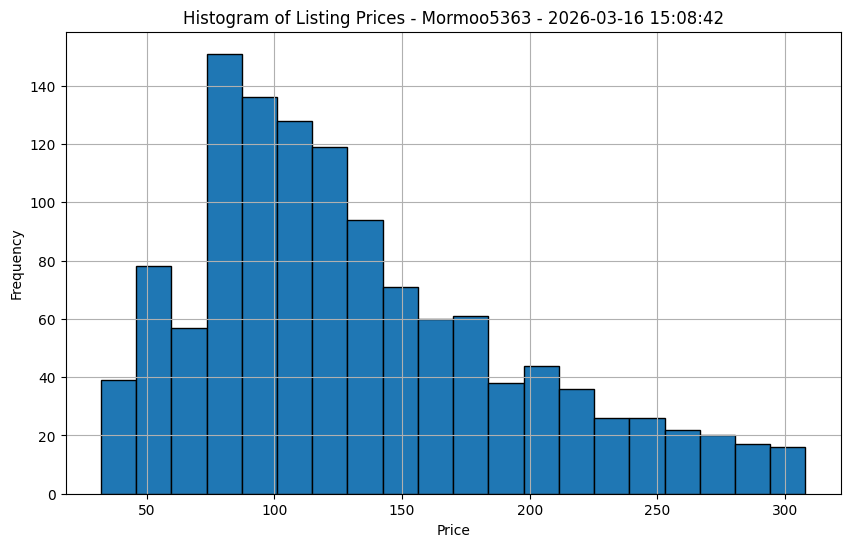

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df_no_outliers['price'], bins=20, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title(f'Histogram of Listing Prices - {student_id} - {today_date}')
plt.grid(True)
plt.show()

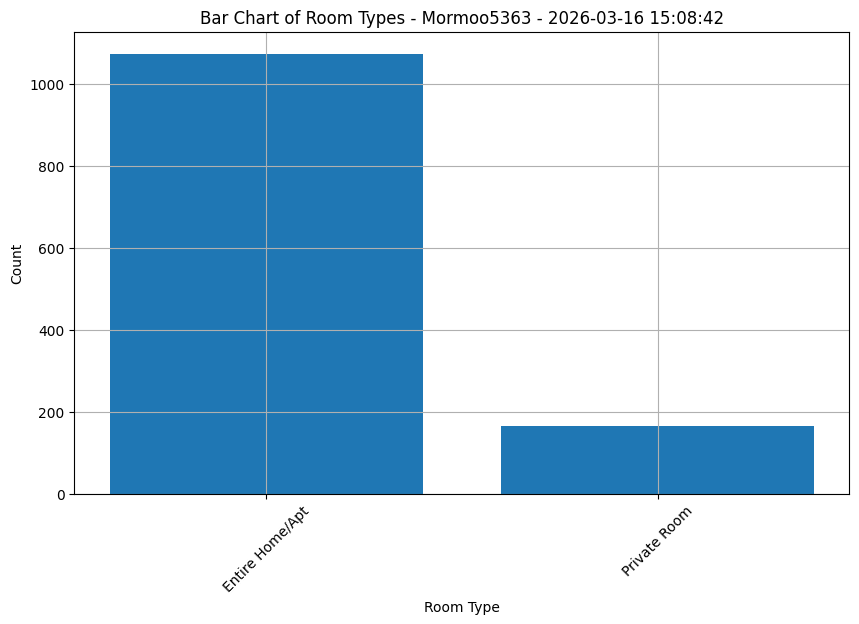

In [17]:
room_type_counts = df_no_outliers['room_type'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(room_type_counts.index, room_type_counts.values)
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.title(f'Bar Chart of Room Types - {student_id} - {today_date}')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

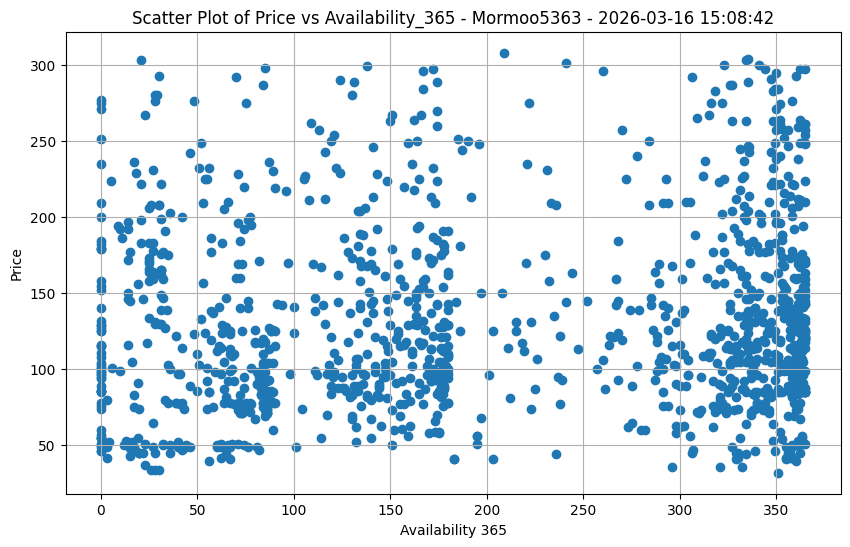

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df_no_outliers['availability_365'], df_no_outliers['price'])
plt.xlabel('Availability 365')
plt.ylabel('Price')
plt.title(f'Scatter Plot of Price vs Availability_365 - {student_id} - {today_date}')
plt.grid(True)
plt.show()

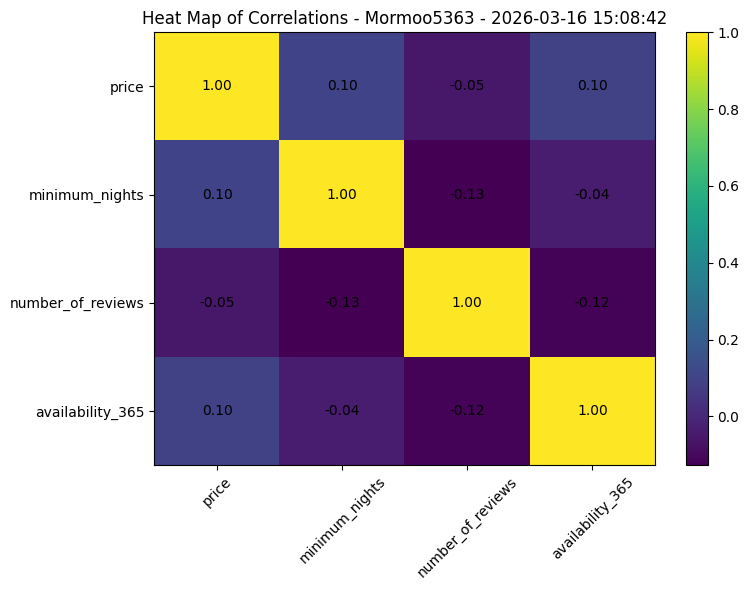

In [19]:
correlation_columns = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365']
correlation_matrix = df_no_outliers[correlation_columns].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=45)
plt.yticks(range(len(correlation_columns)), correlation_columns)
plt.title(f'Heat Map of Correlations - {student_id} - {today_date}')

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha='center', va='center')

plt.tight_layout()
plt.show()